<a href="https://colab.research.google.com/github/godmsqls/Advanced-Major-Practice/blob/main/AMP_week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 임계값에 따라 이진 영상 변화

무엇을 대상으로 할 지 정해야 함

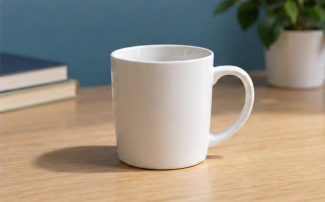

- 전역 임계값

- 적응형 임계값
  
  위치마다 서로 다른 T 값 적용 -> 잡음 발생



---


IF) 물체가 배경보다 어두운 경우


```
cv2.THRESH_BINARY
cv2.THRESH_BINARY_INV # 물체를 흰색으로..!!
```

IF) 경계값에 높인 픽셀

임계값 T = 150


```
L = 150

cv2.THRESH_BINARY = 0
cv2.THRESH_BINARY_INV = 255
```




a의 흰색 픽셀 수: 13869 개
b의 흰색 픽셀 수: 6905 개


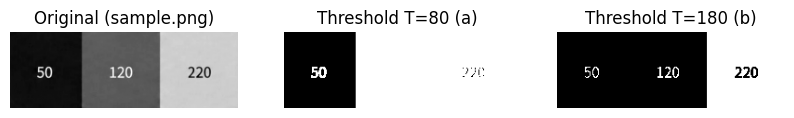

In [29]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('sample.png', 0)

# 2. 임계값(Threshold) 적용
# a: T=80 적용 (임계값 80 초과인 픽셀은 255, 이하는 0으로 변환)
_, a = cv2.threshold(img, 80, 255, cv2.THRESH_BINARY)

# b: T=180 적용 (임계값 180 초과인 픽셀은 255, 이하는 0으로 변환)
_, b = cv2.threshold(img, 180, 255, cv2.THRESH_BINARY)

# 3. np.count_nonzero()를 이용한 흰색 픽셀(값이 255인 요소) 수 계산
count_a = np.count_nonzero(a == 255)
count_b = np.count_nonzero(b == 255)

# 4. 지정된 형식으로 결과 출력
print(f"a의 흰색 픽셀 수: {count_a} 개")
print(f"b의 흰색 픽셀 수: {count_b} 개")

# 5. 코랩 환경에서 결과 시각화
plt.figure(figsize=(10, 3))

plt.subplot(1, 3, 1)
plt.title('Original (sample.png)')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Threshold T=80 (a)')
plt.imshow(a, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Threshold T=180 (b)')
plt.imshow(b, cmap='gray')
plt.axis('off')

plt.show()

뭐가 완벽하면 1, 아니면 0




```
np.logical_and(P, G).sum() / np.logical_or(P, G).sum()
```



## 오츠 방법 : 영상에서 임계값 찾기

1. 각 임계값으로 두 집단을 나눔
2. 집단 사이 차이가 가장 큰 T를 선택


In [30]:
import cv2

img = cv2.imread('sample.png', cv2.IMREAD_GRAYSCALE)
t_otsu, mask = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(t_otsu)

150.0
